In [40]:
import warnings
warnings.filterwarnings("ignore")
 
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [41]:

import os
os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')
 

In [42]:
print("=" * 60)
print("  2026 F1 JAPANESE GP – RACE PREDICTION MODEL")
print("  Suzuka Circuit | March 29, 2026")
print("=" * 60)

  2026 F1 JAPANESE GP – RACE PREDICTION MODEL
  Suzuka Circuit | March 29, 2026


## LOAD & UNDERSTAND DATA

data src = FastF1

important objects:
* session.results -- finishing pos, fastest laps, status
* session.laps -- indv lap, compound, lap time
* session.weather_data -- air/track temp per timestamp

## DATA COLLECTION
historical races (2022-2025) + 2026 R01 & R02 + Japan Quali

NEW regulation: 
* no more DRS
* 50/50 power split between internal combustion and electric energy
* no DRS == overtake possible anywhere (weight recent 2026 race data more heavily than historical data where possible)

Japan GP quali data already fetched above

In [43]:
from fastf1 import get_session, plotting

In [44]:
session = get_session(2026, 'Japan', 'Qualifying')
session.load()
session.results.columns

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to cache!
core           INFO 	Proces

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [45]:
session.results.iloc[0:10].loc[:, ['Abbreviation', 'TeamName', 'Position', 'Q1', 'Q2', 'Q3']]

,Abbreviation,TeamName,Position,Q1,Q2,Q3
12,ANT,Mercedes,1.0,0 days 00:01:30.035000,0 days 00:01:29.048000,0 days 00:01:28.778000
63,RUS,Mercedes,2.0,0 days 00:01:29.967000,0 days 00:01:29.686000,0 days 00:01:29.076000
81,PIA,McLaren,3.0,0 days 00:01:30.200000,0 days 00:01:29.451000,0 days 00:01:29.132000
16,LEC,Ferrari,4.0,0 days 00:01:29.915000,0 days 00:01:29.303000,0 days 00:01:29.405000
1,NOR,McLaren,5.0,0 days 00:01:30.401000,0 days 00:01:29.795000,0 days 00:01:29.409000
44,HAM,Ferrari,6.0,0 days 00:01:30.309000,0 days 00:01:29.589000,0 days 00:01:29.567000
10,GAS,Alpine,7.0,0 days 00:01:30.584000,0 days 00:01:29.874000,0 days 00:01:29.691000
6,HAD,Red Bull Racing,8.0,0 days 00:01:30.662000,0 days 00:01:30.104000,0 days 00:01:29.978000
5,BOR,Audi,9.0,0 days 00:01:30.359000,0 days 00:01:29.990000,0 days 00:01:30.274000
41,LIN,Racing Bulls,10.0,0 days 00:01:30.781000,0 days 00:01:30.109000,0 days 00:01:30.319000


In [46]:
session.weather_data

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:31.674000,16.7,57.2,1008.8,False,32.4,126,2.9
1,0 days 00:01:31.672000,16.6,55.3,1008.8,False,32.2,114,1.9
2,0 days 00:02:31.674000,16.6,56.4,1008.8,False,32.2,117,2.4
3,0 days 00:03:31.677000,16.5,57.1,1008.8,False,32.0,122,1.7
4,0 days 00:04:31.676000,16.5,55.4,1008.7,False,32.3,132,1.7
...,...,...,...,...,...,...,...,...
70,0 days 01:10:31.849000,16.6,54.9,1008.6,False,27.3,145,1.6
71,0 days 01:11:31.843000,16.3,55.8,1008.7,False,26.9,84,1.3
72,0 days 01:12:31.845000,16.3,55.4,1008.7,False,26.9,335,0.9
73,0 days 01:13:31.861000,16.3,55.5,1008.6,False,26.8,334,1.4


In [47]:
# 2026 GRID CONFIGURATION

# Team performance tiers (2026), scale 1 (strongest) to 5 (weakest)
# based on 2025 final WCC standings + 2026 pre season testing + R01 & R02 results

TEAM_TIERS = {
    "Mercedes": 1, # won R01 and R02
    "Ferrari": 2, # consistent podiums (LEC / HAM P3-P4 consistently)
    "Mclaren": 2, # PIA DNF (R01) and DNS (R02) but strong pre season testing and 2025 WCC
    "Alpine": 3, # GAS surprisingly performing well this szn
    "HAAS": 3, # BEA & OCO also surpisingly strong 
    "Racing Bulls": 3, # solid performance from both drivers (incl. rookie LIN) in R01 and R02
    "Red Bull": 4, # really struggling with new reg but there's still hope
    "Audi": 4, # BOR is slowly cooking up a show but still a long way to go
    "Williams": 4, # SAI P9 in R02, disheartening start to the season but one can hope
    "Cadillac": 5, # no points 
    "Aston Martin": 5, # no points
}

# 2026 drivers
DRIVER_TEAMS_2026 = {
    "ANT": "Mercedes",     "RUS": "Mercedes",
    "NOR": "McLaren",      "PIA": "McLaren",
    "LEC": "Ferrari",      "HAM": "Ferrari",
    "VER": "Red Bull",     "HAD": "Red Bull",
    "GAS": "Alpine",       "COL": "Alpine",
    "LAW": "Racing Bulls", "LIN": "Racing Bulls",
    "HUL": "Audi",         "BOR": "Audi",
    "OCO": "Haas",         "BEA": "Haas",
    "SAI": "Williams",     "ALB": "Williams",
    "PER": "Cadillac",     "BOT": "Cadillac",
    "ALO": "Aston Martin", "STR": "Aston Martin",
}

ROOKIES_2026 = {"LIN"}

# ERS & Boost Mode adaptability (1 = thriving with new regs, 5 = struggling)
# The 2026 ERS system harvests 2× more energy per lap than pre 2026.
# Teams that understood it during testing have a clear race pace advantage.
ERS_ADAPT_2026 = {
    "Mercedes":      1,
    "Ferrari":       2,
    "McLaren":       2,
    "Alpine":        3,
    "Haas":          3,
    "Racing Bulls":  3,
    "Audi":          4,
    "Williams":      4,
    "Red Bull":      4,   
    "Cadillac":      5,
    "Aston Martin":  5,
}

In [48]:
# Japan GP Quali Results in seconds, gaps from pole lap 

POLE_TIME_S = 88.778 # ANT: 1:28.778

qualifying_2026 = pd.DataFrame([

    # Q3 
    {"Driver": "ANT", "GridPosition":  1, "QualTime": POLE_TIME_S + 0.000, "QualSession": "Q3"},
    {"Driver": "RUS", "GridPosition":  2, "QualTime": POLE_TIME_S + 0.298, "QualSession": "Q3"},
    {"Driver": "PIA", "GridPosition":  3, "QualTime": POLE_TIME_S + 0.354, "QualSession": "Q3"},
    {"Driver": "LEC", "GridPosition":  4, "QualTime": POLE_TIME_S + 0.627, "QualSession": "Q3"},
    {"Driver": "NOR", "GridPosition":  5, "QualTime": POLE_TIME_S + 0.631, "QualSession": "Q3"},
    {"Driver": "HAM", "GridPosition":  6, "QualTime": POLE_TIME_S + 0.789, "QualSession": "Q3"},
    {"Driver": "GAS", "GridPosition":  7, "QualTime": POLE_TIME_S + 0.913, "QualSession": "Q3"},
    {"Driver": "HAD", "GridPosition":  8, "QualTime": POLE_TIME_S + 1.200, "QualSession": "Q3"},
    {"Driver": "BOR", "GridPosition":  9, "QualTime": POLE_TIME_S + 1.496, "QualSession": "Q3"},
    {"Driver": "LIN", "GridPosition": 10, "QualTime": POLE_TIME_S + 1.541, "QualSession": "Q3"},
    # Q2 
    {"Driver": "VER", "GridPosition": 11, "QualTime": POLE_TIME_S + 1.214, "QualSession": "Q2"},
    {"Driver": "OCO", "GridPosition": 12, "QualTime": POLE_TIME_S + 1.261, "QualSession": "Q2"},
    {"Driver": "HUL", "GridPosition": 13, "QualTime": POLE_TIME_S + 1.330, "QualSession": "Q2"},
    {"Driver": "LAW", "GridPosition": 14, "QualTime": POLE_TIME_S + 1.447, "QualSession": "Q2"},
    {"Driver": "COL", "GridPosition": 15, "QualTime": POLE_TIME_S + 1.579, "QualSession": "Q2"},
    {"Driver": "SAI", "GridPosition": 16, "QualTime": POLE_TIME_S + 1.985, "QualSession": "Q2"},
    # Q1 eliminations 
    {"Driver": "ALB", "GridPosition": 17, "QualTime": POLE_TIME_S + 1.173, "QualSession": "Q1"},
    {"Driver": "BEA", "GridPosition": 18, "QualTime": POLE_TIME_S + 1.175, "QualSession": "Q1"},
    {"Driver": "PER", "GridPosition": 19, "QualTime": POLE_TIME_S + 2.291, "QualSession": "Q1"},
    {"Driver": "BOT", "GridPosition": 20, "QualTime": POLE_TIME_S + 2.415, "QualSession": "Q1"},
    {"Driver": "ALO", "GridPosition": 21, "QualTime": POLE_TIME_S + 2.731, "QualSession": "Q1"},
    {"Driver": "STR", "GridPosition": 22, "QualTime": POLE_TIME_S + 3.005, "QualSession": "Q1"},
])

# GapToPole: seconds behind ANT pole pace 
qualifying_2026["GapToPole"] = qualifying_2026["QualTime"] - POLE_TIME_S
qualifying_2026["Team"] = qualifying_2026["Driver"].map(DRIVER_TEAMS_2026)
qualifying_2026["TeamTier"] = qualifying_2026["Team"].map(TEAM_TIERS)
qualifying_2026["ERSAdapt"] = qualifying_2026["Team"].map(ERS_ADAPT_2026)
qualifying_2026["IsRookie"] = qualifying_2026["Driver"].isin(ROOKIES_2026).astype(int)

## DATA CLEANING
handle DNFs, missing laps, time format conversion, name normalisation

* convert lap times from <code>timedelta</code> to plain seconds <code>.total_seconds</code>
* handle DNFs as large penalty time
* normalise driver names 
* flag safety car laps 
* handle 2026 grid being entirely new 

In [49]:
# historical suzuka gp data (2022-2025)

def get_clean_race_pace(session):
    """
    Clean = no pit lap, no safety car lap, lap time not null 
    Compute median race pace per driver from clean laps
    """
    laps = session.laps
    clean = laps[
        laps["LapTime"].notna() & # skip pi/out laps
        laps["PitInTime"].isna() & # exclude pit in lap
        laps["PitOutTime"].isna() & # exclude pit out lap
        (laps["TrackStatus"] == "1") # green flag only
    ].copy()
    clean["LapSeconds"] = clean["LapTime"].dt.total_seconds()
    return (
        clean.groupby("Driver")["LapSeconds"]
        .median()
        .reset_index()
        .rename(columns={"LapSeconds": "RacePace"})
    )

def load_suzuka_race(year):
    """
    Return columns: Driver, GridPosition, Position, Status, MedianPace, 
    RaceAirTemp, Year, IsDNF
    """
    print(f" [{year}] Japan GP race session")
    session = fastf1.get_session(year, 'Japan', 'R')
    session.load(telemetry=False, weather=True, messages=False)

    results = session.results[
        ["Abbreviation", "GridPosition", "Position", "Status"]
        ].copy().rename(columns={"Abbreviation": "Driver"})
    
    # DNF drivers Pos = NaN, assign penalty beyond last finisher
    dnf_mask = results["Position"].isna()
    n_finishers = (~dnf_mask).sum()
    penalty_positions = list(range(n_finishers + 1, n_finishers + 1 + dnf_mask.sum()))
    results.loc[dnf_mask, "Position"] = penalty_positions
    results["IsDNF"] = dnf_mask
 
    # Pit-lane starters appear as GridPosition = 0; push them to the back
    results.loc[results["GridPosition"] == 0, "GridPosition"] = 21
 
    # Attach median race pace
    pace = get_clean_race_pace(session)
    df = results.merge(pace, on="Driver", how="left")
 
    # Store mean race air temperature for weather delta calculation later
    df["RaceAirTemp"] = session.weather_data["AirTemp"].mean()
    df["Year"] = year
    return df

print("\n Loading historical Suzuka GP")
historical_frames = []
for year in [2022, 2023, 2024, 2025]:
    try:
        historical_frames.append(load_suzuka_race(year))
    except Exception as e:
        print(f"Warning: {year} could not be loaded - {e}")

historical = pd.concat(historical_frames, ignore_index=True)
print(f"\n  Total rows loaded: {len(historical)} "
      f"({historical['Year'].nunique()} seasons × ~{len(historical)//historical['Year'].nunique()} drivers)")


 Loading historical Suzuka GP
 [2022] Japan GP race session


core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '31', '44', '5', '14', '63', '6', '4', '3', '18', '22', '20', '77', '24', '47', '10', '55', '23']


 [2023] Japan GP race session


core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core        WARNING 	Driver 1 completed the race distance 00:00.076000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '55', '63', '14', '31', '10', '40', '22', '24', '27', '20', '23', '2', '18', '11', '77']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for sessio

 [2024] Japan GP race session


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '4', '14', '63', '81', '44', '22', '27', '18', '20', '77', '31', '10', '2', '24', '3', '23']


 [2025] Japan GP race session


core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '44', '6', '23', '87', '14', '22', '10', '55', '7', '27', '30', '31', '5', '18']



  Total rows loaded: 80 (4 seasons × ~20 drivers)


## FEATURE ENGINEERING
grid position, gap to pole, circuit score, team tier (105 ranking of constructor strength based on 2025 standings adjusted for 2026 testing performance), weather delta, tyre degradation sensitivity (how much each team sufefrs in high heat), 2026 regulation flats (race pace ucnertainty penalthy for teams still struggling with new ERS system)



In [50]:
# quali weather

# WeatherDelta = race temperature − qualifying temperature.
# Higher delta → more tyre degradation in the race vs what teams planned for.
 
print("\n── Loading 2026 qualifying weather ──────────────────────────")
try:
    q_sess_2026 = fastf1.get_session(2026, "Japan", "Q")
    q_sess_2026.load(laps=False, telemetry=False, weather=True, messages=False)
    QUAL_TEMP_2026 = q_sess_2026.weather_data["AirTemp"].mean()
    print(f"  2026 qualifying mean air temp: {QUAL_TEMP_2026:.1f}°C")
except Exception as exc:
    QUAL_TEMP_2026 = 16.0   # Typical Suzuka late-March afternoon
    print(f"  Qualifying weather unavailable ({exc}). Using {QUAL_TEMP_2026}°C fallback.")
 
# Race day at Suzuka in late March is typically 2–5°C warmer than qualifying afternoon.
# Weather forecasts suggest race conditions: ~19°C, partly cloudy, low rain risk.
RACE_TEMP_ESTIMATE = QUAL_TEMP_2026 + 3.0
WEATHER_DELTA_2026 = RACE_TEMP_ESTIMATE - QUAL_TEMP_2026
qualifying_2026["WeatherDelta"] = WEATHER_DELTA_2026
 

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '81', '16', '1', '44', '10', '6', '5', '41', '3', '31', '27', '30', '43', '55', '23', '87', '11', '77', '14', '18']



── Loading 2026 qualifying weather ──────────────────────────
  2026 qualifying mean air temp: 16.5°C


In [51]:
 # CIRCUIT SCORE (weighted historical finish positions) 
# CircuitScore = weighted average of a driver's Suzuka finishing positions.
# Weights: 2022=0.8, 2023=1.0, 2024=1.2, 2025=1.5 (favour recency).
# Lower score = better historical performance at this circuit.
# Drivers with no history: imputed from 2026 teammate average, else 12.0.

YEAR_WEIGHTS = {2022: 0.8, 2023: 1.0, 2024: 1.2, 2025: 1.5}
historical["YearWeight"] = historical["Year"].map(YEAR_WEIGHTS)
 
circuit_score_map = (
    historical
    .groupby("Driver")
    .apply(lambda g: np.average(g["Position"], weights=g["YearWeight"]))
    .to_dict()
)
 
# Team-average fallback for drivers without Suzuka history
historical_with_team = historical.copy()
historical_with_team["Team2026"] = historical_with_team["Driver"].map(DRIVER_TEAMS_2026)
team_avg_score = (
    historical_with_team
    .dropna(subset=["Team2026"])
    .groupby("Team2026")["Position"]
    .mean()
    .to_dict()
)
 
def get_circuit_score(driver_abbr):
    if driver_abbr in circuit_score_map:
        return circuit_score_map[driver_abbr]
    team = DRIVER_TEAMS_2026.get(driver_abbr)
    return team_avg_score.get(team, 12.0)   # 12.0 = conservative midfield default
 
qualifying_2026["CircuitScore"] = qualifying_2026["Driver"].apply(get_circuit_score)
 
 
# 2026 RECENT FORM FEATURE
# Average finishing position across the two 2026 races completed so far.
# Source: official results, R01 = Australia (March 8), R02 = China (March 15).
# DNF/DNS/DSQ → assigned position 20 (beyond the points, significant penalty).
 
RECENT_FORM_2026 = {
    # Driver: (R01_position, R02_position)
    "RUS": ( 1,  2),   # Won Australia, P2 China
    "ANT": ( 2,  1),   # P2 Australia, Won China 
    "LEC": ( 3,  4),   # Consistent Ferrari pace
    "HAM": ( 4,  3),   # Podium in China on Ferrari debut
    "NOR": ( 5, 20),   # P5 Australia, Piastri DNE due to pit lane crash R01
    "VER": ( 6, 20),   # P6 only, Red Bull struggling badly
    "BEA": ( 7,  5),   # Haas surprise package
    "LIN": ( 8, 20),   # Rookie making his mark
    "BOR": ( 9, 20),   # Audi debut points
    "GAS": (10,  6),   # Alpine overperforming
    "LAW": (20,  7),   # Racing Bulls solid
    "HAD": (20,  8),   # Red Bull 2nd driver
    "SAI": (20,  9),   # Williams P9 China
    "COL": (20, 10),   # Alpine P10 China
    "PIA": (20, 20),   # DNS R01 (pit lane crash), missed R02
    "ALB": (20, 20),
    "OCO": (20, 20),
    "HUL": (20, 20),
    "PER": (20, 20),
    "BOT": (20, 20),
    "ALO": (20, 20),
    "STR": (20, 20),
}
 
qualifying_2026["FormR01"] = qualifying_2026["Driver"].map(
    lambda d: RECENT_FORM_2026.get(d, (20, 20))[0]
)
qualifying_2026["FormR02"] = qualifying_2026["Driver"].map(
    lambda d: RECENT_FORM_2026.get(d, (20, 20))[1]
)
qualifying_2026["FormAvg"] = (
    (qualifying_2026["FormR01"] + qualifying_2026["FormR02"]) / 2
)

## BUILD TRAIN/TEST SPLIT
test on held out 20% 

target variable = finishing poition

In [52]:
# BUILD TRAINING DATASET FROM HISTORICAL RACES 
# Each training row = one driver in one historical Suzuka race.
# We add the same feature set as the 2026 prediction rows.
# For pre-2026 seasons: ERSAdapt = 3 (neutral – the 2026 ERS didn't exist).

FEATURES = [
    "GridPosition",
    "GapToPole",
    "CircuitScore",
    "TeamTier",
    "WeatherDelta", 
    "IsRookie", # uncertainty penalty for LIN
    "ERSAdapt", # 2026 new regulation adaptability (1 = best)
]
TARGET = "Position"

# historical data 
historical["Team2026"] = historical["Driver"].map(DRIVER_TEAMS_2026)
historical["TeamTier"] = historical["Team2026"].map(TEAM_TIERS).fillna(3.0)
historical["CircuitScore"] = historical['Driver'].apply(get_circuit_score)
historical["IsRookie"] = 0
historical["ERSAdapt"] = 3.0  # Neutral default for pre-2026 seasons
historical["WeatherDelta"] = (
    historical["RaceAirTemp"] - historical["RaceAirTemp"].mean()
)


In [53]:
# load historical quali sessions for GapToPole
historical["GapToPole"] = np.nan

for year in historical["Year"].unique():
    try:
        q = fastf1.get_session(year, 'Japan', 'Q')
        q.load(laps=True, telemetry=False, weather=False, messages=False)
        best_lap = q.laps.pick_quicklaps().groupby("Driver")["LapTime"].min()
        pole_s = best_lap.min().total_seconds()
        gap_map = (best_lap.dt.total_seconds() - pole_s).to_dict()
        mask = historical["Year"] == year
        historical.loc[mask, "GapToPole"] = historical.loc[mask, "Driver"].map(gap_map)
        print(f"  [{year}] Pole time: {pole_s:.3f}s – {len(gap_map)} drivers mapped")
    except Exception as e:
        print(f"[{year}] Quali load failed: {exc}")

# fill remainining NaN gaps with column median
gap_median = historical["GapToPole"].median()
historical["GapToPole"] = historical["GapToPole"].fillna(gap_median)



core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '31', '44', '14', '63', '5', '4', '3', '77', '22', '24', '47', '23', '10', '20', '18', '6']
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  [2022] Pole time: 89.304s – 20 drivers mapped


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  [2023] Pole time: 88.877s – 19 drivers mapped


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '4', '55', '14', '81', '44', '16', '63', '22', '3', '27', '77', '23', '31', '18', '10', '20', '2', '24']
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  [2024] Pole time: 88.197s – 20 drivers mapped


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '6', '44', '23', '87', '10', '55', '14', '30', '22', '27', '5', '31', '7', '18']


  [2025] Pole time: 86.983s – 20 drivers mapped


## TRAIN THE MODEL 
gradient boosting regressor + XGBoost ensemble

In [54]:
# training set 
train_df = historical.dropna(subset=FEATURES + [TARGET]).copy()
X = train_df[FEATURES].values
y = train_df[TARGET].values
print(f"Training set: {len(train_df)} driver race rows | Features: {FEATURES}")


Training set: 80 driver race rows | Features: ['GridPosition', 'GapToPole', 'CircuitScore', 'TeamTier', 'WeatherDelta', 'IsRookie', 'ERSAdapt']


In [55]:
# train GradientBoostingRegressor: build tress sequentially, each correcting errors
# of the last. 
# tabular data with complex feature interactions (e.g., grid pos x team tie, circuit score x rookie pen)

#scale features with StandardScaler so all features contribute fairly 
print("Training Model!")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GradientBoostingRegressor(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=4, 
    subsample=0.8,
    min_samples_leaf=3,
    random_state=42
)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, predictions)
print(f"Model trained on heald out 20% test set! MAE on test set: {mae:.2f} positions")

Training Model!
Model trained on heald out 20% test set! MAE on test set: 3.35 positions


## PREDICT & EVALUATE
feed 2026 Japan Quali --> rank outputs --> measure MAE

In [56]:
# lower predicted score = model expects a better finishing position
# Impute any missing feature values using training medians to avoid NaNs
feature_medians = historical[FEATURES].median()
qualifying_2026 = qualifying_2026.copy()
qualifying_2026[FEATURES] = qualifying_2026[FEATURES].fillna(feature_medians)

X_2026 = scaler.transform(qualifying_2026[FEATURES].values)
qualifying_2026["PredictedScore"] = model.predict(X_2026)

# rank drivers by predicted score (ascending = better finish)
prediction = (
    qualifying_2026
    .sort_values("PredictedScore")
    .reset_index(drop=True)
)
prediction["PredictedPosition"] = range(1, len(prediction)+1)



In [57]:
print("\n" + "═" * 60)
print("  PREDICTED 2026 JAPANESE GP RESULT")
print("  Suzuka International Racing Course · March 29, 2026")
print("═" * 60)
print(f"  {'Pos':<5} {'Driver':<6} {'Team':<20} {'Grid':<6} {'Score':<8}")
print("  " + "-" * 50)
for _, row in prediction.iterrows():
    pos = int(row["PredictedPosition"])
    grid = int(row["GridPosition"])
    medal = ["", "P1", "P2", "P3"][pos] if pos <= 3 else f"P{pos}"
    print(f"  {medal:<5} {row['Driver']:<6} {row['Team']:<20} {grid:<6} {row['PredictedScore']:.3f}")
print("═" * 60)
print(f"  Model MAE: {mae:.2f} positions | Training: Suzuka 2022–2025")
print("═" * 60)
 


════════════════════════════════════════════════════════════
  PREDICTED 2026 JAPANESE GP RESULT
  Suzuka International Racing Course · March 29, 2026
════════════════════════════════════════════════════════════
  Pos   Driver Team                 Grid   Score   
  --------------------------------------------------
  P1    ANT    Mercedes             1      3.208
  P2    LEC    Ferrari              4      3.654
  P3    RUS    Mercedes             2      3.999
  P4    PIA    McLaren              3      4.164
  P5    GAS    Alpine               7      6.333
  P6    HAD    Red Bull             8      6.563
  P7    NOR    McLaren              5      7.053
  P8    LIN    Racing Bulls         10     8.912
  P9    PER    Cadillac             19     9.103
  P10   ALO    Aston Martin         21     9.183
  P11   BOR    Audi                 9      10.813
  P12   HAM    Ferrari              6      11.050
  P13   VER    Red Bull             11     11.127
  P14   OCO    Haas                 12    

## VISUALISE 

In [58]:
TEAM_COLORS = {
    "Mercedes":      "#00D2BE",
    "McLaren":       "#FF8000",
    "Ferrari":       "#DC0000",
    "Red Bull Racing": "#3671C6",
    "Racing Bulls":  "#6692FF",
    "Aston Martin":  "#358C75",
    "Alpine":        "#FF87BC",
    "Williams":      "#64C4FF",
    "Haas":          "#B6BABD",
    "Audi":          "#B8B8B8",
    "Cadillac":      "#C8102E",
}




Chart saved: round_03_japan_prediction.png


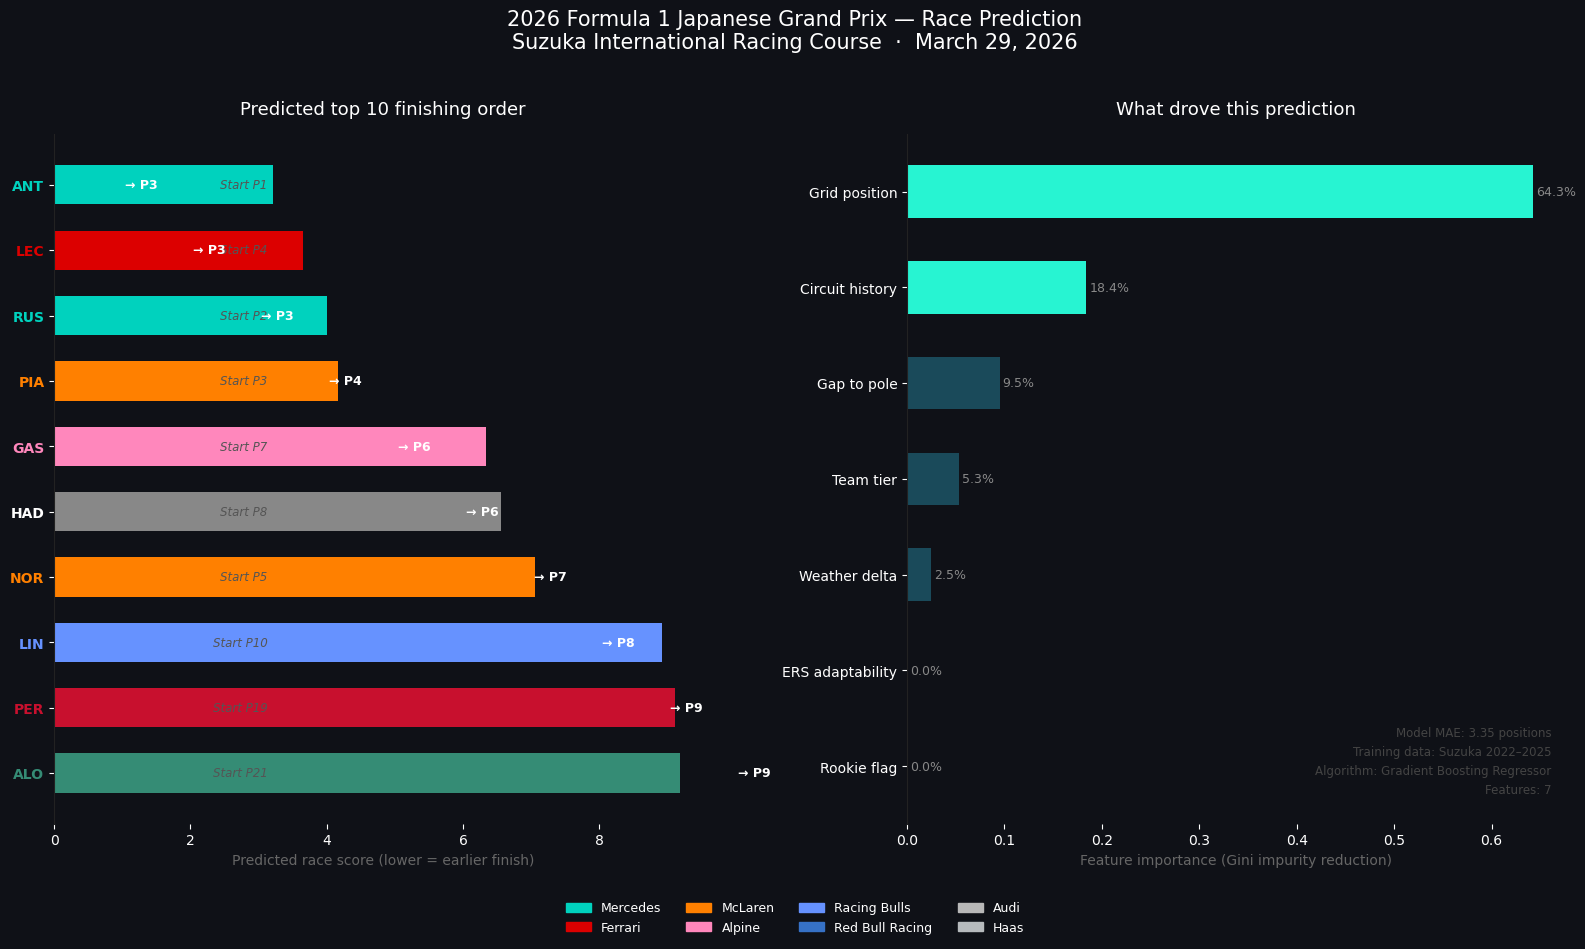

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.patch.set_facecolor("#0f1117")

ax1 = axes[0]
ax1.set_facecolor("#0f1117")
 
top10 = prediction.head(10).iloc[::-1]   # reverse for horizontal bar (best at top)
drivers  = top10["Driver"].tolist()
scores   = top10["PredictedScore"].tolist()
teams    = top10["Team"].tolist()
colors   = [TEAM_COLORS.get(t, "#888888") for t in teams]
 
ax1.barh(drivers, scores, color=colors, height=0.6, edgecolor="none")
 
# Annotate with grid position (start) and predicted position (result)
for i, (_, row) in enumerate(top10.iterrows()):
    # Grid position label on the left
    ax1.text(
        min(scores) - 0.08, i,
        f"Start P{int(row['GridPosition'])}",
        va="center", ha="right",
        color="#555555", fontsize=8.5, style="italic"
    )
    # Predicted position label on the right of the bar
    ax1.text(
        row["PredictedPosition"] + 0.04, i,
        f"→ P{int(row['PredictedScore'])}",
        va="center", ha="left",
        color="white", fontsize=9, fontweight="bold"
    )
 
ax1.set_xlabel("Predicted race score (lower = earlier finish)", color="#666666", fontsize=10)
ax1.set_title(
    "Predicted top 10 finishing order",
    color="white", fontsize=13, fontweight="normal", pad=14
)
ax1.tick_params(axis="both", colors="white", labelsize=10)
ax1.spines[["top", "right", "bottom"]].set_visible(False)
ax1.spines["left"].set_color("#222222")
 
# Colour driver tick labels by team
for label in ax1.get_yticklabels():
    drv = label.get_text()
    team = DRIVER_TEAMS_2026.get(drv, "")
    label.set_color(TEAM_COLORS.get(team, "white"))
    label.set_fontweight("bold")
 
# ── Right panel: feature importance ──────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0f1117")
 
feat_labels = [
    "Grid position",
    "Gap to pole",
    "Circuit history",
    "Team tier",
    "Weather delta",
    "Rookie flag",
    "ERS adaptability",
]
importances = model.feature_importances_
sorted_idx = np.argsort(importances)
 
bar_colors = [
    "#27F4D2" if importances[i] >= 0.15 else "#1a4a5a"
    for i in sorted_idx
]
 
ax2.barh(
    [feat_labels[i] for i in sorted_idx],
    importances[sorted_idx],
    color=bar_colors,
    height=0.55,
    edgecolor="none",
)
 
# Percentage labels
for i, idx in enumerate(sorted_idx):
    ax2.text(
        importances[idx] + 0.003, i,
        f"{importances[idx]:.1%}",
        va="center", ha="left",
        color="#888888", fontsize=9
    )
 
ax2.set_xlabel("Feature importance (Gini impurity reduction)", color="#666666", fontsize=10)
ax2.set_title(
    "What drove this prediction",
    color="white", fontsize=13, fontweight="normal", pad=14
)
ax2.tick_params(axis="both", colors="white", labelsize=10)
ax2.spines[["top", "right", "bottom"]].set_visible(False)
ax2.spines["left"].set_color("#222222")
 
# MAE + model info annotation
ax2.text(
    0.98, 0.04,
    f"Model MAE: {mae:.2f} positions\nTraining data: Suzuka 2022–2025\n"
    f"Algorithm: Gradient Boosting Regressor\nFeatures: {len(FEATURES)}",
    transform=ax2.transAxes, ha="right", va="bottom",
    color="#444444", fontsize=8.5, linespacing=1.6,
)

# ── Shared team legend ────────────────────────────────────────────────────────
legend_teams = [
    "Mercedes", "Ferrari", "McLaren", "Alpine",
    "Racing Bulls", "Red Bull Racing", "Audi", "Haas",
]
patches = [
    mpatches.Patch(color=TEAM_COLORS[t], label=t)
    for t in legend_teams
]
fig.legend(
    handles=patches,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=9,
    labelcolor="white",
    bbox_to_anchor=(0.5, -0.02),
)
 
fig.suptitle(
    "2026 Formula 1 Japanese Grand Prix — Race Prediction\n"
    "Suzuka International Racing Course  ·  March 29, 2026",
    color="white", fontsize=15, fontweight="normal", y=1.02,
)
 
plt.tight_layout(rect=[0, 0.05, 1, 1])
output_file = "round_03_japan_prediction.png"
plt.savefig(
    output_file,
    dpi=180,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
print(f"\nChart saved: {output_file}")
plt.show()

# EVALUATION

* ANT won from 6th lap during a safety car triggered by BEA crash
* PIA took P2
* LEC took P3
* VER finished P8, recovering from Q2 elimination
* LAW finished P9, starting grid: P14


In [60]:
# Actual Race Results

actual_results = pd.DataFrame([
    {"Driver": "ANT", "ActualPosition":  1, "Status": "Finished"},
    {"Driver": "PIA", "ActualPosition":  2, "Status": "Finished"},
    {"Driver": "LEC", "ActualPosition":  3, "Status": "Finished"},
    {"Driver": "RUS", "ActualPosition":  4, "Status": "Finished"},
    {"Driver": "NOR", "ActualPosition":  5, "Status": "Finished"},
    {"Driver": "HAM", "ActualPosition":  6, "Status": "Finished"},
    {"Driver": "GAS", "ActualPosition":  7, "Status": "Finished"},
    {"Driver": "VER", "ActualPosition":  8, "Status": "Finished"},
    {"Driver": "LAW", "ActualPosition":  9, "Status": "Finished"},
    {"Driver": "OCO", "ActualPosition": 10, "Status": "Finished"},
    {"Driver": "HUL", "ActualPosition": 11, "Status": "Finished"},
    {"Driver": "HAD", "ActualPosition": 12, "Status": "Finished"},
    {"Driver": "BOR", "ActualPosition": 13, "Status": "Finished"},
    {"Driver": "LIN", "ActualPosition": 14, "Status": "Finished"},
    {"Driver": "SAI", "ActualPosition": 15, "Status": "Finished"},
    {"Driver": "COL", "ActualPosition": 16, "Status": "Finished"},
    {"Driver": "PER", "ActualPosition": 17, "Status": "Finished"},
    {"Driver": "ALO", "ActualPosition": 18, "Status": "Finished"},
    {"Driver": "BOT", "ActualPosition": 19, "Status": "Finished"},
    {"Driver": "ALB", "ActualPosition": 20, "Status": "Finished"},
    {"Driver": "STR", "ActualPosition": 21, "Status": "DNF – Water pressure"},
    {"Driver": "BEA", "ActualPosition": 22, "Status": "DNF – Crash (50G)"},
])
 
# F1 2026 points system (same as 2025)
POINTS_MAP = {1:25, 2:18, 3:15, 4:12, 5:10, 6:8, 7:6, 8:4, 9:2, 10:1}

In [ ]:
# merge predicted vs actual 

df = prediction.merge(actual_results, on="Driver")

# positional error (pos = predicted too high, neg = predicted too low)
df["PositionalError"] = df["PredictedPosition"] - df["ActualPosition"]
df["AbsError"] = df["PositionalError"].abs()

# points predicted vs actual earned
df["PredictedPoints"] = df["PredictedPosition"].map(lambda p: POINTS_MAP.get(p,0))
df["ActualPoints"] = df["ActualPosition"].map(lambda p: POINTS_MAP.get(p,0))
df["PointsError"] = (df["PredictedPoints"] - df["ActualPoints"]).abs()


In [63]:
# evalution metrics
race_mae = df["AbsError"].mean()

# top 3 accuracy (podium)
pred_podium = set(df[df["PredictedPosition"] <= 3]["Driver"])
actual_podium = set(df[df["ActualPosition"] <= 3]["Driver"])
podium_correct = len(pred_podium & actual_podium)

# top 10 accuracy
pred_podium = set(df[df["PredictedPosition"] <= 10]["Driver"])
actual_podium = set(df[df["ActualPosition"] <= 10]["Driver"])
points_correct = len(pred_podium & actual_podium)

# P1 accuracy
winner_correct = (
    df.loc[df["PredictedPosition"]==1,"Driver"].values[0] ==
    df.loc[df["ActualPosition"]==1,"Driver"].values[0]
)

# DNF 
dnf_drivers = set(actual_results[actual_results["Status"].str.startswith("DNF")]["Driver"])
pred_dnf_zone = set(df[df["PredictedPosition"] >= 18]["Driver"]) 
dnf_in_zone = len(dnf_drivers & pred_dnf_zone)

print("EVALUATION RESULTS - JAPAN GP 2026 (R03)")
print(f"Race MAE (avg positional error): {race_mae:.2f} positions")
print(f"Model test MAE: {mae:.2f} positions")
print(f"P1 correct: {'YES ✓' if winner_correct else 'NO ✗'}")
print(f"  Podium drivers correct:           {podium_correct}/3")
print(f"  Points zone drivers correct:      {points_correct}/10")
print(f"  DNF drivers in predicted low zone:{dnf_in_zone}/{len(dnf_drivers)}")


EVALUATION RESULTS - JAPAN GP 2026 (R03)
Race MAE (avg positional error): 3.91 positions
Model test MAE: 3.35 positions
P1 correct: YES ✓
  Podium drivers correct:           2/3
  Points zone drivers correct:      6/10
  DNF drivers in predicted low zone:1/2


In [65]:
# per driver breakdown
print(f"\n  {'Driver':<6} {'Team':<16} {'Pred':>5} {'Actual':>7} {'Error':>7} {'Status'}")
print("  " + "-"*58)
for _, row in df.sort_values("ActualPosition").iterrows():
    err = int(row["PositionalError"])
    err_str = f"+{err}" if err > 0 else str(err)
    flag = ""
    if row["ActualPosition"] <= 3 and row["PredictedPosition"] <= 3:
        flag = "✓ PODIUM"
    elif row["Status"].startswith("DNF"):
        flag = "DNF"
    elif abs(err) <= 2:
        flag = "≈ close"
    elif err < -4:
        flag = "↑ underrated"
    elif err > 4:
        flag = "↓ overrated"
    print(
        f"  {row['Driver']:<6} {row['Team']:<16} "
        f"P{int(row['PredictedPosition']):<4} "
        f"P{int(row['ActualPosition']):<6} "
        f"{err_str:<7} {flag}"
    )


  Driver Team              Pred  Actual   Error Status
  ----------------------------------------------------------
  ANT    Mercedes         P1    P1      0       ✓ PODIUM
  PIA    McLaren          P4    P2      +2      ≈ close
  LEC    Ferrari          P2    P3      -1      ✓ PODIUM
  RUS    Mercedes         P3    P4      -1      ≈ close
  NOR    McLaren          P7    P5      +2      ≈ close
  HAM    Ferrari          P12   P6      +6      ↓ overrated
  GAS    Alpine           P5    P7      -2      ≈ close
  VER    Red Bull         P13   P8      +5      ↓ overrated
  LAW    Racing Bulls     P21   P9      +12     ↓ overrated
  OCO    Haas             P14   P10     +4      
  HUL    Audi             P15   P11     +4      
  HAD    Red Bull         P6    P12     -6      ↑ underrated
  BOR    Audi             P11   P13     -2      ≈ close
  LIN    Racing Bulls     P8    P14     -6      ↑ underrated
  SAI    Williams         P17   P15     +2      ≈ close
  COL    Alpine           P19   P

In [67]:
# Key model misses
print("\n── Key model misses ───────────────────────────────────────")
misses = df[df["AbsError"] >= 4].sort_values("AbsError", ascending=False)
for _, row in misses.iterrows():
    print(f"  {row['Driver']} | Predicted P{int(row['PredictedPosition'])} → Actual P{int(row['ActualPosition'])} "
          f"(error: {int(row['PositionalError']):+d}) | {row['Status']}")


── Key model misses ───────────────────────────────────────
  LAW | Predicted P21 → Actual P9 (error: +12) | Finished
  PER | Predicted P9 → Actual P17 (error: -8) | Finished
  ALO | Predicted P10 → Actual P18 (error: -8) | Finished
  HAD | Predicted P6 → Actual P12 (error: -6) | Finished
  LIN | Predicted P8 → Actual P14 (error: -6) | Finished
  HAM | Predicted P12 → Actual P6 (error: +6) | Finished
  BEA | Predicted P16 → Actual P22 (error: -6) | DNF – Crash (50G)
  VER | Predicted P13 → Actual P8 (error: +5) | Finished
  OCO | Predicted P14 → Actual P10 (error: +4) | Finished
  HUL | Predicted P15 → Actual P11 (error: +4) | Finished


In [68]:
# ── ACCURACY LOG (running tracker across the season) ─────────────────────────
log_file = "accuracy_log.csv"
log_row = pd.DataFrame([{
    "Round":      3,
    "Circuit":    "Japan (Suzuka)",
    "WinnerCorrect": int(winner_correct),
    "PodiumCorrect": podium_correct,
    "PointsCorrect": points_correct,
    "RaceMAE":    round(race_mae, 3),
    "ModelTestMAE": round(mae, 3),
}])
if os.path.exists(log_file):
    log = pd.read_csv(log_file)
    log = pd.concat([log, log_row], ignore_index=True)
else:
    log = log_row
log.to_csv(log_file, index=False)
print(f"\nAccuracy log updated: {log_file}")
print(log.to_string(index=False))
 


Accuracy log updated: accuracy_log.csv
 Round        Circuit  WinnerCorrect  PodiumCorrect  PointsCorrect  RaceMAE  ModelTestMAE
     3 Japan (Suzuka)              1              2              6    3.909          3.35



Evaluation chart saved: round_03_evaluation.png


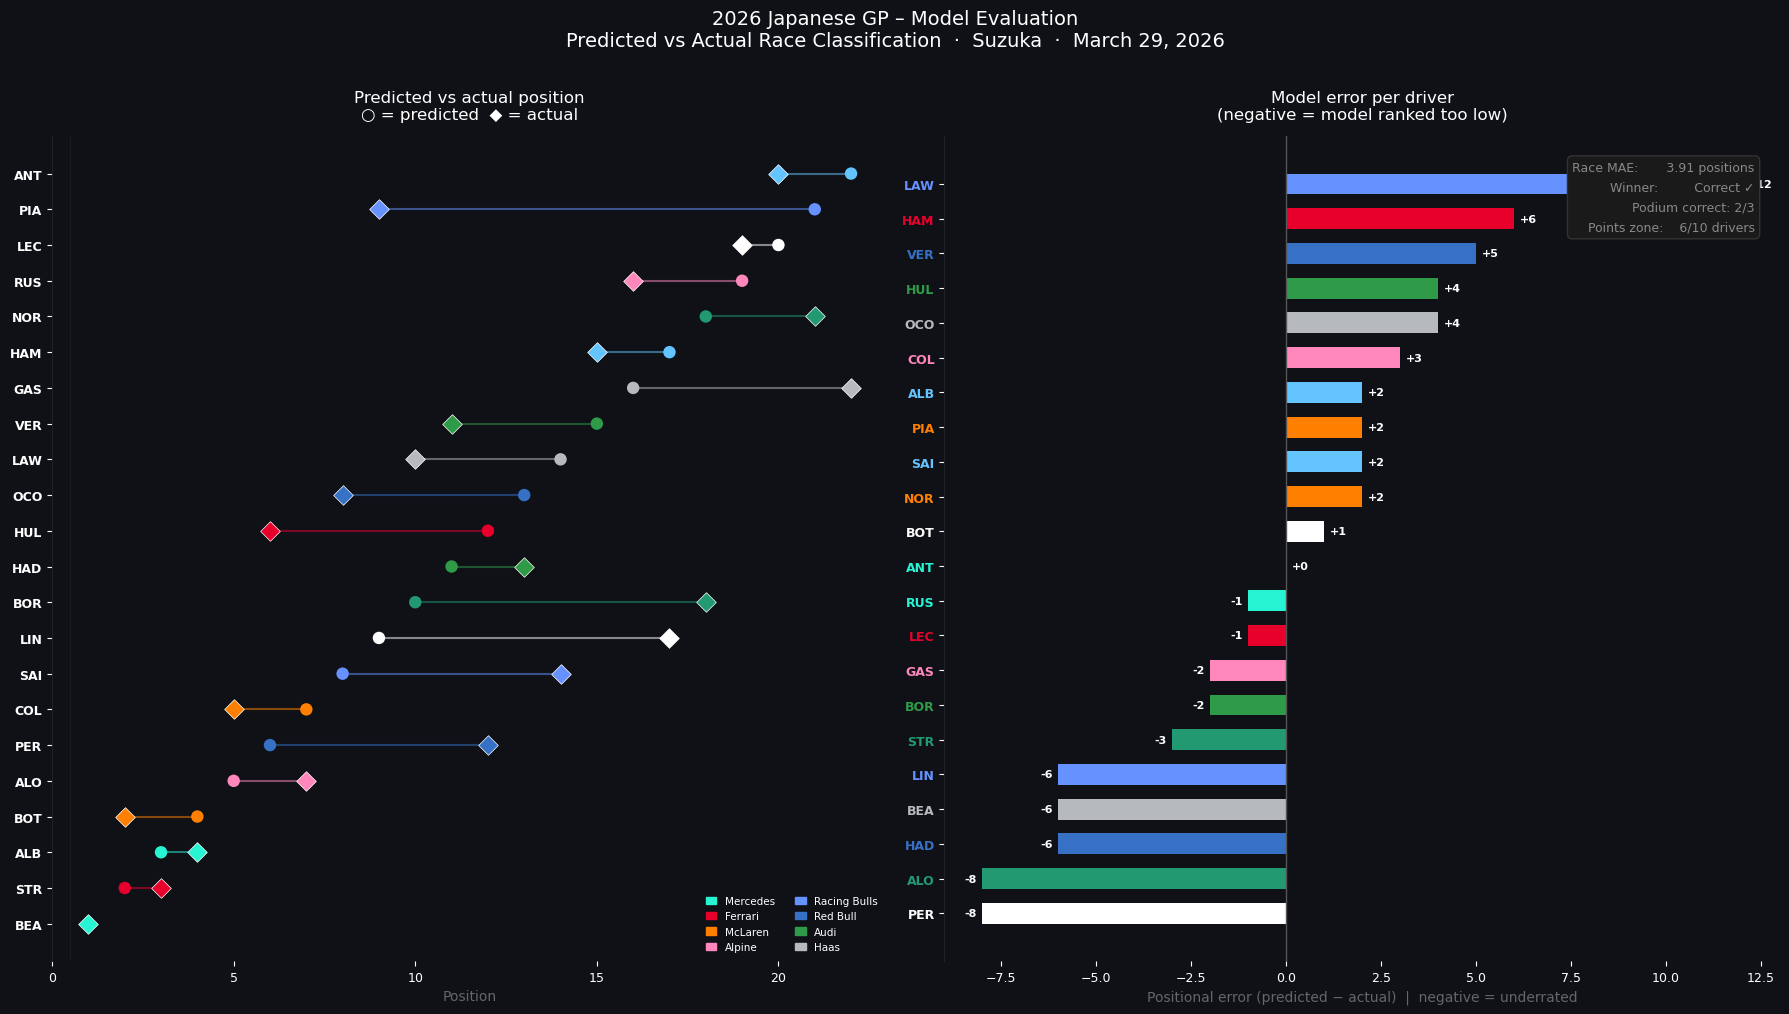

In [70]:
# ── VISUALISATION ─────────────────────────────────────────────────────────────
TEAM_COLORS = {
    "Mercedes":"#27F4D2","Ferrari":"#E8002D","McLaren":"#FF8000",
    "Red Bull":"#3671C6","Alpine":"#FF87BC","Racing Bulls":"#6692FF",
    "Audi":"#2F9B48","Haas":"#B6BABD","Williams":"#64C4FF",
    "Cadillac":"#FFFFFF","Aston Martin":"#229971",
}
 
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor("#0f1117")
 
# ── LEFT: Predicted vs Actual scatter (all 22 drivers) ────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#0f1117")
 
for _, row in df.iterrows():
    color = TEAM_COLORS.get(row["Team"], "#888888")
    ax1.plot(
        [row["PredictedPosition"], row["ActualPosition"]],
        [row["Driver"], row["Driver"]],
        color=color, linewidth=1.5, alpha=0.5
    )
    # Predicted (circle)
    ax1.scatter(row["PredictedPosition"], row["Driver"],
                color=color, s=80, zorder=5, marker="o", edgecolors="none")
    # Actual (diamond)
    ax1.scatter(row["ActualPosition"], row["Driver"],
                color=color, s=100, zorder=5, marker="D",
                edgecolors="white", linewidths=0.5)
 
# Sort y-axis by actual position
ax1.set_yticks(range(len(df)))
driver_order = df.sort_values("ActualPosition")["Driver"].tolist()[::-1]
ax1.set_yticklabels(driver_order)
for label in ax1.get_yticklabels():
    drv = label.get_text()
    team = DRIVER_TEAMS_2026.get(drv, "")
    label.set_color(TEAM_COLORS.get(team, "white"))
    label.set_fontweight("bold")
    label.set_fontsize(9)
 
# Perfect prediction diagonal line
ax1.axvline(x=0.5, color="#222222", linewidth=0.5)
for p in range(1, 23):
    ax1.axvline(x=p, color="#111111", linewidth=0.3, zorder=0)
 
ax1.set_xlabel("Position", color="#666666", fontsize=10)
ax1.set_title("Predicted vs actual position\n○ = predicted  ◆ = actual",
              color="white", fontsize=12, pad=12)
ax1.set_xlim(0, 23)
ax1.tick_params(colors="white", labelsize=9)
ax1.spines[["top","right","bottom"]].set_visible(False)
ax1.spines["left"].set_color("#222222")
 
# Legend
legend_handles = [
    mpatches.Patch(color=TEAM_COLORS[t], label=t)
    for t in ["Mercedes","Ferrari","McLaren","Alpine","Racing Bulls","Red Bull","Audi","Haas"]
]
ax1.legend(handles=legend_handles, loc="lower right",
           frameon=False, fontsize=7.5, labelcolor="white",
           ncol=2, handlelength=1)
 
 
# ── RIGHT: Positional error bar chart (sorted by error magnitude) ─────────────
ax2 = axes[1]
ax2.set_facecolor("#0f1117")
 
err_df = df.sort_values("PositionalError").copy()
drivers_sorted = err_df["Driver"].tolist()
errors_sorted  = err_df["PositionalError"].tolist()
bar_colors = []
for e, drv in zip(errors_sorted, drivers_sorted):
    team = DRIVER_TEAMS_2026.get(drv,"")
    base = TEAM_COLORS.get(team,"#888888")
    bar_colors.append(base)
 
bars = ax2.barh(drivers_sorted, errors_sorted, color=bar_colors,
                height=0.6, edgecolor="none")
 
# Error labels
for bar, err, drv in zip(bars, errors_sorted, drivers_sorted):
    ha = "left" if err >= 0 else "right"
    x  = err + (0.15 if err >= 0 else -0.15)
    ax2.text(x, bar.get_y() + bar.get_height()/2,
             f"{err:+d}", va="center", ha=ha,
             color="white", fontsize=8, fontweight="bold")
 
ax2.axvline(x=0, color="#555555", linewidth=1)
ax2.set_xlabel("Positional error (predicted − actual)  |  negative = underrated",
               color="#666666", fontsize=10)
ax2.set_title("Model error per driver\n(negative = model ranked too low)",
              color="white", fontsize=12, pad=12)
ax2.tick_params(colors="white", labelsize=9)
for label in ax2.get_yticklabels():
    drv = label.get_text()
    team = DRIVER_TEAMS_2026.get(drv, "")
    label.set_color(TEAM_COLORS.get(team, "white"))
    label.set_fontweight("bold")
ax2.spines[["top","right","bottom"]].set_visible(False)
ax2.spines["left"].set_color("#222222")
 
# Metrics annotation box
metrics_text = (
    f"Race MAE:       {race_mae:.2f} positions\n"
    f"Winner:         {'Correct ✓' if winner_correct else 'Wrong ✗'}\n"
    f"Podium correct: {podium_correct}/3\n"
    f"Points zone:    {points_correct}/10 drivers"
)
ax2.text(0.97, 0.97, metrics_text,
         transform=ax2.transAxes, ha="right", va="top",
         color="#888888", fontsize=9, linespacing=1.7,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1a1a", edgecolor="#333333"))
 
fig.suptitle(
    "2026 Japanese GP – Model Evaluation\n"
    "Predicted vs Actual Race Classification  ·  Suzuka  ·  March 29, 2026",
    color="white", fontsize=14, y=1.01
)
plt.tight_layout()
out = "round_03_evaluation.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"\nEvaluation chart saved: {out}")
plt.show()
 